In [1]:
# Hypothesis testing in python

A/B Testing: provides a way to check outcomes of competing scenarios and decide which way to proceed. A/B testing lets you compare scenarios to see which best achieves some goal.

In [2]:
import pandas as pd
import numpy as np
from scipy.stats import norm
from scipy.stats import t
import pingouin
import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.proportion import proportions_ztest

sales_df = pd.read_csv('Data/sales.csv')
sales_df.columns = sales_df.columns.str.strip()
sales_df['order_value_EUR'] = pd.to_numeric(sales_df['order_value_EUR'].str.replace(',', ''))

insurance_df = pd.read_csv('Data/insurance.csv')
print(insurance_df.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


In [3]:
# Calculate the proportion of late shipments, the mean cases where the late column is "Yes"
smoker_prop_samp = (insurance_df['smoker'] == 'yes').mean()

# Print the results
print('Sample proportion of smokers:', smoker_prop_samp)

Sample proportion of smokers: 0.20478325859491778


The proportion of late shipments in the sample is 0.204, or 20.4%.

Since variables have arbitrary ranges and units, we need to standardize them. For example, a hypothesis test that gave different answers if the variables were in Euros instead of US dollars would be of little value. Standardization avoids that. The z-score is a standardized measure of the difference between the sample statistic and the hypothesized statistic.

In [4]:
# Calculate the sample proportion of smokers
smoker_prop_samp = (insurance_df['smoker'] == 'yes').mean()

# Generate a bootstrap distribution of the smoker proportion
insurance_boot_distn = []
for i in range(5000):
    insurance_boot_distn.append(
        (insurance_df.sample(frac=1, replace=True)['smoker'] == 'yes').mean()
    )

In [5]:
# Hypothesize that the proportion of smokers is 20%
smoker_prop_hyp = 0.20

# Calculate the standard error
std_error = np.std(insurance_boot_distn, ddof=1)

# Find z-score of smoker_prop_samp
z_score = (smoker_prop_samp - smoker_prop_hyp) / std_error

# Print z_score
print('Z score:', z_score)

Z score: 0.4307867598216175


The z-score is a standardized measure of the difference between the sample statistic and the hypothesized statistic.

Hypothesis tests are used to determine whether the sample statistic lies in the tails of the null distribution. However, the way that the alternative hypothesis is phrased affects which tail(s) we are interested in. The tails of the distribution that are relevant depend on whether the alternative hypothesis refers to "greater than", "less than", or "differences between."

In [6]:
# Calculate the z-score of smoker_prop_samp
z_score = (smoker_prop_samp - smoker_prop_hyp) / std_error  
# Calculate the p-value
p_value = 1 - norm.cdf(z_score, loc = 0, scale = 1)
# Print the p-value
print('P value:', p_value)

P value: 0.33331171377628555


**Analysis**: there's about a 33% chance of seeing a smoker proportion this far from 20% (or further) purely from random sampling, if the true rate actually is 20%.
Since 0.331 is way above the standard α = 0.05 threshold, we fail to reject the null hypothesis. Conclusion: our data doesn't provide evidence that the true smoker proportion differs from 20% — the ~20.5% we're seeing is easily explained by ordinary sampling noise.

The **p-value** is a measure of the amount of evidence to reject the null hypothesis or not. By comparing the p-value to the significance level, you can make a decision about which hypothesis to support. If the p-value is less than or equal to the significance level, you reject the null hypothesis.

In [7]:
# Calculate 95% confidence interval using quantile method
lower = np.quantile(insurance_boot_distn, 0.025)
upper = np.quantile(insurance_boot_distn, 0.975)

# Print the confidence interval
print((lower, upper))

(0.18310911808669655, 0.226457399103139)


We fail to reject the null hypothesis. There is no statistically significant evidence that the true proportion of smokers in this population differs from 20%. The observed sample proportion (20.5%) is well within the range of values we'd expect from ordinary sampling variation around a true rate of 20%.

Type I error (False positive): rejecting the null hypothesis when in fact the null hypothesis is true

Type II error (False negative): failing to reject the null hypothesis when in fact the null hypothesis is false

## Hypothesis Testing Workflow

1. **Identify** the population parameter that is hypothesized about
2. **Specify** the null and alternative hypotheses
3. **Determine** the (standardized) test statistic and corresponding null distribution
4. **Conduct** the hypothesis test in Python
5. **Measure** evidence against the null hypothesis and compare to the significance level
6. **Interpret** the results in the context of the original problem

In [8]:
# Get group means, standard deviations, and counts by smoker status
xbar_yes = insurance_df[insurance_df['smoker'] == 'yes']['charges'].mean()
xbar_no  = insurance_df[insurance_df['smoker'] == 'no']['charges'].mean()
s_yes    = insurance_df[insurance_df['smoker'] == 'yes']['charges'].std()
s_no     = insurance_df[insurance_df['smoker'] == 'no']['charges'].std()
n_yes    = insurance_df[insurance_df['smoker'] == 'yes']['charges'].count()
n_no     = insurance_df[insurance_df['smoker'] == 'no']['charges'].count()

In [9]:
# Calculate the numerator of the test statistic
numerator = xbar_no - xbar_yes
# Calculate the denominator of the test statistic
denominator = np.sqrt(s_no ** 2 / n_no + s_yes ** 2 / n_yes)
# Calculate the test statistic
t_stat = numerator / denominator
# Print the test statistic
print('T statistics:', t_stat)

T statistics: -32.75188776634183


The process for calculating p-values is to start with the sample statistic, standardize it to get a test statistic, then transform it via a cumulative distribution function.
Using a sample standard deviation to estimate the standard error is computationally easier than using bootstrapping. However, to correct for the approximation, you need to use a t-distribution when transforming the test statistic to get the p-value.

As you increase the degrees of freedom, the t-distribution PDF and CDF curves get closer to those of a normal distribution.

In [10]:
# Calculate the degrees of freedom
degrees_of_freedom = n_no + n_yes - 2
# Calculate the p-value from the test stat
p_value = t.cdf(t_stat, df=degrees_of_freedom)
# Print the p_value
print('P-value:', p_value)

P-value: 1.669959217641446e-173


We reject the null hypothesis because the p-value is greater than the statistical significance level of 0.1.
When the standard error is estimated from the sample standard deviation and sample size, the test statistic is transformed into a p-value using the t-distribution.

**Degrees of freedom**: maximum number of logically independent values in the data sample or how many values in your data are still free to change, once you've locked in the stuff you calculated from it (like a mean)

In [11]:
# Get group means, standard deviations, and counts by region
stats = insurance_df.groupby('region')['charges'].agg(['mean', 'std', 'count'])
xbar_southeast, s_southeast, n_southeast = stats.loc['southeast']
xbar_northwest, s_northwest, n_northwest = stats.loc['northwest']

# Calculate the numerator of the test statistic
numerator = xbar_southeast - xbar_northwest
# Calculate the denominator of the test statistic
denominator = np.sqrt(s_southeast ** 2 / n_southeast + s_northwest ** 2 / n_northwest)
# Calculate the test statistic
t_stat = numerator / denominator
print('T statistics:', t_stat)

# Calculate the degrees of freedom
degrees_of_freedom = n_southeast + n_northwest - 2
# Calculate the p-value (two-tailed, since there's no directional hypothesis here)
p_value = 2 * (1 - t.cdf(abs(t_stat), df=degrees_of_freedom))
print('P value:',p_value)

T statistics: 2.425150305315581
P value: 0.01555879085988865


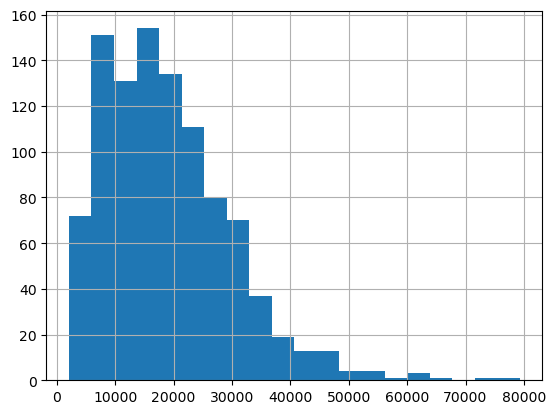

In [12]:
# Calculate the difference between order value and cost
sales_df['diff'] = sales_df['order_value_EUR'] - sales_df['cost']
# Find the mean of the diff column
xbar_diff = sales_df['diff'].mean()
# Find the standard deviation of the diff column
s_diff = sales_df['diff'].std()
# Plot a histogram of diff with 20 bins
sales_df['diff'].hist(bins = 20)
plt.show()

In [13]:
# Conduct a t-test on diff
test_results = pingouin.ttest(x=sales_df['diff'], 
                               y=0, 
                               alternative="two-sided")
print(test_results)

# Conduct a paired t-test on order_value_EUR and cost
paired_test_results = pingouin.ttest(x=sales_df['order_value_EUR'], 
                                      y=sales_df['cost'], 
                                      paired=True, 
                                      alternative="two-sided")
# Print the paired test results
print(paired_test_results)

                T  dof alternative          p_val                  CI95  \
T_test  55.011223  999   two-sided  1.424319e-304  [18314.94, 19669.92]   

         cohen_d  power        BF10  
T_test  1.739608    1.0  2.077e+300  
                T  dof alternative          p_val                  CI95  \
T_test  55.011223  999   two-sided  1.424319e-304  [18314.94, 19669.92]   

         cohen_d  power        BF10  
T_test  0.333855    1.0  2.077e+300  


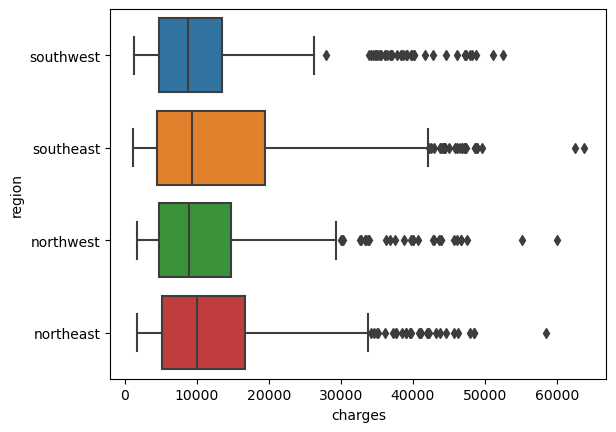

In [14]:
# Calculate the mean charges for each region
xbar_charges_by_region = insurance_df.groupby("region")['charges'].mean()
# Calculate the standard deviation of charges for each region
s_charges_by_region = insurance_df.groupby("region")['charges'].std()
# Boxplot of region vs. charges
sns.boxplot(x="charges", y="region", data=insurance_df)
plt.show()

In [15]:
# Run an ANOVA for charges across region
alpha = 0.1
anova_results = pingouin.anova(data=insurance_df, dv='charges', between='region')
# Print anova_results
print(anova_results)

   Source  ddof1  ddof2         F     p_unc       np2
0  region      3   1334  2.969627  0.030893  0.006634


In [16]:
# Perform a pairwise t-test on charges, grouped by region
pairwise_results = pingouin.pairwise_tests(data=insurance_df, dv="charges", between="region") 
# Print pairwise_results
print(pairwise_results)

  Contrast          A          B  Paired  Parametric         T         dof  \
0   region  northeast  northwest   False        True  1.128139  646.753468   
1   region  northeast  southeast   False        True -1.380165  679.413390   
2   region  northeast  southwest   False        True  1.183014  646.647993   
3   region  northwest  southeast   False        True -2.425150  677.642458   
4   region  northwest  southwest   False        True  0.079565  648.000000   
5   region  southeast  southwest   False        True  2.454116  683.096482   

  alternative     p_unc   BF10    hedges  
0   two-sided  0.259679  0.163  0.088466  
1   two-sided  0.167990  0.216 -0.104003  
2   two-sided  0.237238  0.173  0.092763  
3   two-sided  0.015562  1.501 -0.182498  
4   two-sided  0.936608  0.088  0.006234  
5   two-sided  0.014372  1.608  0.185107  


In [17]:
# Modify the pairwise t-tests to use Bonferroni p-value adjustment
pairwise_results = pingouin.pairwise_tests(data=insurance_df, 
                                            dv="charges",
                                            between="region",
                                            padjust="bonf")
# Print pairwise_results
print(pairwise_results)

  Contrast          A          B  Paired  Parametric         T         dof  \
0   region  northeast  northwest   False        True  1.128139  646.753468   
1   region  northeast  southeast   False        True -1.380165  679.413390   
2   region  northeast  southwest   False        True  1.183014  646.647993   
3   region  northwest  southeast   False        True -2.425150  677.642458   
4   region  northwest  southwest   False        True  0.079565  648.000000   
5   region  southeast  southwest   False        True  2.454116  683.096482   

  alternative     p_unc    p_corr p_adjust   BF10    hedges  
0   two-sided  0.259679  1.000000     bonf  0.163  0.088466  
1   two-sided  0.167990  1.000000     bonf  0.216 -0.104003  
2   two-sided  0.237238  1.000000     bonf  0.173  0.092763  
3   two-sided  0.015562  0.093374     bonf  1.501 -0.182498  
4   two-sided  0.936608  1.000000     bonf  0.088  0.006234  
5   two-sided  0.014372  0.086230     bonf  1.608  0.185107  


| Comparison | Technique | Investigation |
|---|---|---|
| A proportion vs. a hypothesized value | Bootstrap + z-score | Is the smoker rate really 20%? |
| A mean vs. a hypothesized value (0) | One-sample t-test | Is average profit per order really 0? |
| Two related measurements on the same rows | Paired t-test | order_value_EUR vs. cost |
| Two independent groups' means | Two-sample t-test | Smoker vs. non-smoker charges; southeast vs. northwest charges |
| 3+ independent groups' means | ANOVA | Charges across all four regions at once |
| Which specific groups differ, after ANOVA | Pairwise t-tests (Bonferroni-adjusted) | Southeast vs. northwest/southwest charges |

In [18]:
# Calculate the sample proportion of smokers
p_hat = (insurance_df['smoker'] == 'yes').mean()
# Hypothesize that the proportion of smokers is 20%
p_0 = 0.20
# Calculate the sample size
n = len(insurance_df)

In [19]:
# Calculate the numerator and denominator of the test statistic
numerator = p_hat - p_0
denominator = np.sqrt(p_0 * (1 - p_0) / n)
# Calculate the test statistic
z_score = numerator / denominator
# Calculate the p-value from the z-score
p_value = 1 - norm.cdf(z_score)
# Print the p-value
print('P-value:', p_value)

P-value: 0.3309058414155477


In [20]:
p_hats = insurance_df.groupby('sex')['smoker'].apply(lambda x: (x == 'yes').mean())
ns = insurance_df.groupby('sex').size()

# Calculate the pooled estimate of the population proportion
p_hat = (p_hats["male"] * ns["male"] + p_hats["female"] * ns["female"]) / (ns["male"] + ns["female"])
# Calculate p_hat one minus p_hat
p_hat_times_not_p_hat = p_hat * (1 - p_hat)


In [21]:
# Divide this by each of the sample sizes and then sum
p_hat_times_not_p_hat_over_ns = p_hat_times_not_p_hat / ns["male"] + p_hat_times_not_p_hat / ns["female"]
# Calculate the standard error
std_error = np.sqrt(p_hat_times_not_p_hat_over_ns)
# Calculate the z-score
z_score = (p_hats["male"] - p_hats["female"]) / std_error
# Calculate the p-value from the z-score
p_value = 1 - norm.cdf(z_score)
# Print p_value
print('P-value:', p_value)

P-value: 0.002662057082160274


In [23]:
# Count the smoker column values for each sex
smoker_by_sex = insurance_df.groupby('sex')['smoker'].value_counts()
print(smoker_by_sex)

# Create an array of the "yes" counts for each sex
success_counts = np.array([smoker_by_sex['male']['yes'], smoker_by_sex['female']['yes']])
# Create an array of the total number of rows in each sex group
n = np.array([smoker_by_sex['male'].sum(), smoker_by_sex['female'].sum()])
# Run a z-test on the two proportions
stat, p_value = proportions_ztest(count=success_counts, nobs=n, alternative="larger")
# Print the results
print('Stat:', stat, 'P-value:', p_value)

sex     smoker
female  no        547
        yes       115
male    no        517
        yes       159
Name: count, dtype: int64
Stat: 2.7867402154855503 P-value: 0.002662057082160266


**Explanation**: This is a one-tailed two-proportion z-test comparing smoking rates between males and females, testing whether males smoke at a higher rate (H₀: p_male = p_female; H₁: p_male > p_female). From the counts, 159 of 676 males smoke (23.5%) versus 115 of 662 females (17.4%) — a real ~6 percentage point gap. The test converts that gap into a z-score (2.787) by scaling it against the standard error we'd expect from sampling noise alone, then converts that into a p-value (0.00266) — the probability of seeing a gap this large (or larger) if the true smoking rates were actually equal.

**Analysis**: With p = 0.00266, well below the conventional α = 0.05 threshold, we reject the null hypothesis. There is strong statistical evidence that males have a significantly higher smoking rate than females in this dataset — the observed gap (23.5% vs 17.4%) is very unlikely to be due to random sampling variation alone. Unlike the earlier sex/smoker test where the proportions were nearly identical and the result was inconclusive, this dataset shows a clear and statistically significant difference.